# LIBs

In [27]:
!pip install split-folders
!pip install gradio -q

In [28]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
from PIL import Image
import shutil
import gradio as gr
import random
from tensorflow.keras.preprocessing import image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

# Data Loading & EDA

In [29]:
DATASET_PATH = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256"
OUTPUT_PATH = "/kaggle/working/garbage_dataset"

In [30]:
classes = sorted(os.listdir(DATASET_PATH))

print(f"Number of Classes : {len(classes)}")
print(classes)

Number of Classes : 10
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [31]:
image_counts = {}

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    image_counts[cls] = len(os.listdir(cls_path))

df = pd.DataFrame({
    "Class": image_counts.keys(),
    "Images": image_counts.values()
})

df.sort_values("Images", ascending=False)

,Class,Images
3,clothes,1892
4,glass,1736
7,plastic,1597
8,shoes,1449
2,cardboard,1411
6,paper,1336
5,metal,930
0,battery,756
1,biological,699
9,trash,453


In [32]:
df.describe()

,Images
count,10.000000
mean,1225.900000
std,485.469406
min,453.000000
25%,799.500000
50%,1373.500000
75%,1560.000000
max,1892.000000


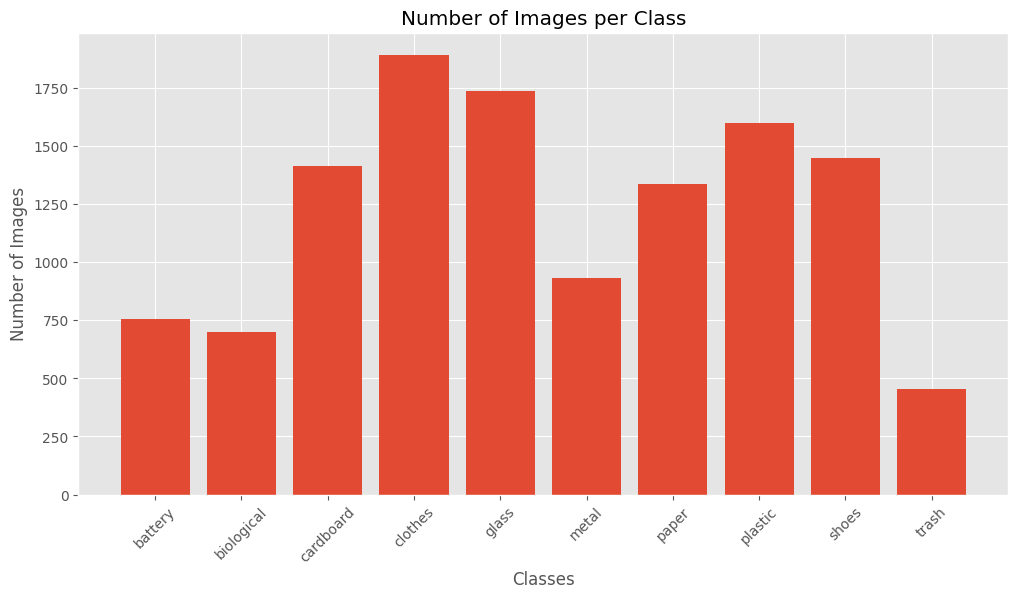

In [33]:
plt.figure(figsize=(12,6))
plt.bar(df["Class"], df["Images"])
plt.xticks(rotation=45)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")

plt.show()

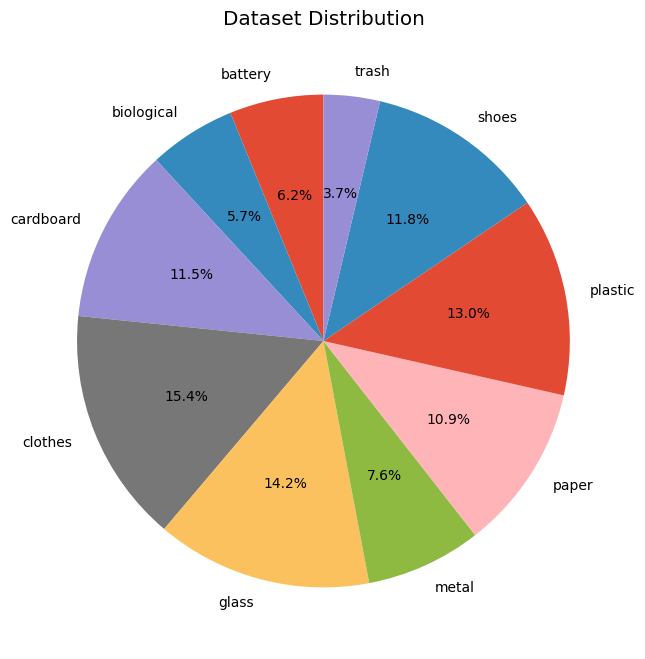

In [34]:
plt.figure(figsize=(8,8))

plt.pie(
    df["Images"],
    labels=df["Class"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Dataset Distribution")

plt.show()

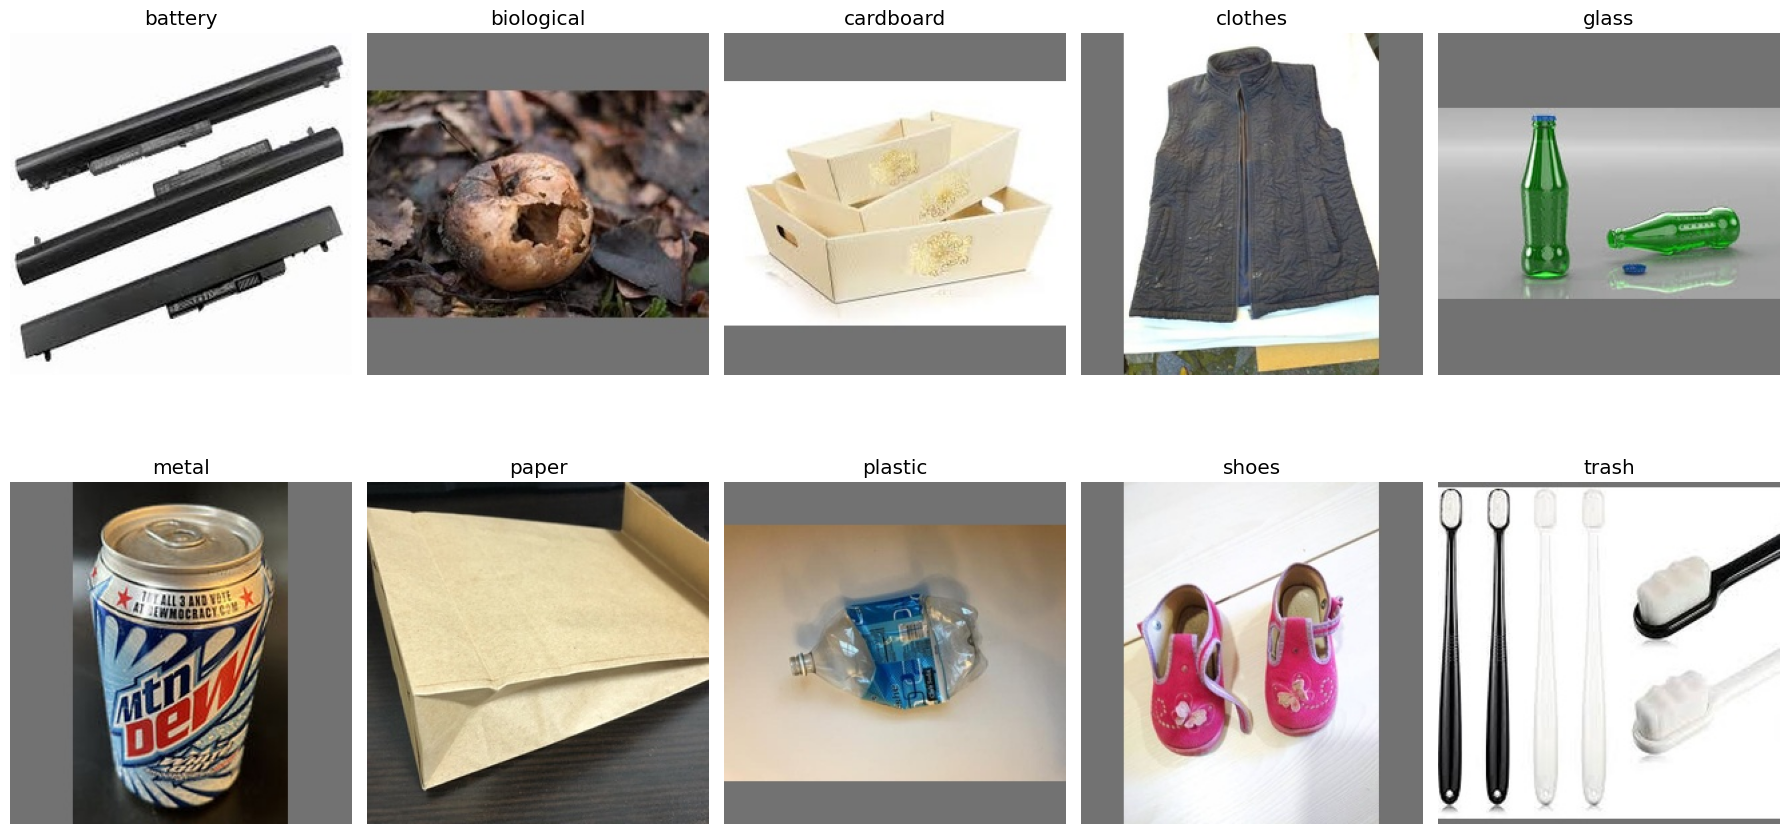

In [35]:
plt.figure(figsize=(18,10))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(DATASET_PATH, cls)))
    img_path = os.path.join(DATASET_PATH, cls, img_name)
    img = Image.open(img_path)
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()

plt.show()

In [36]:
widths = []
heights = []

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(folder)[:100]:
        img = Image.open(os.path.join(folder, img_name))
        w,h = img.size
        widths.append(w)
        heights.append(h)

print("Unique Widths :", np.unique(widths))
print("Unique Heights:", np.unique(heights))

Unique Widths : [256]
Unique Heights: [256]


In [37]:
extensions = {}

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    for img in os.listdir(folder):
        ext = img.split(".")[-1].lower()
        extensions[ext] = extensions.get(ext,0)+1

extensions

{'jpg': 12258, 'jpeg': 1}

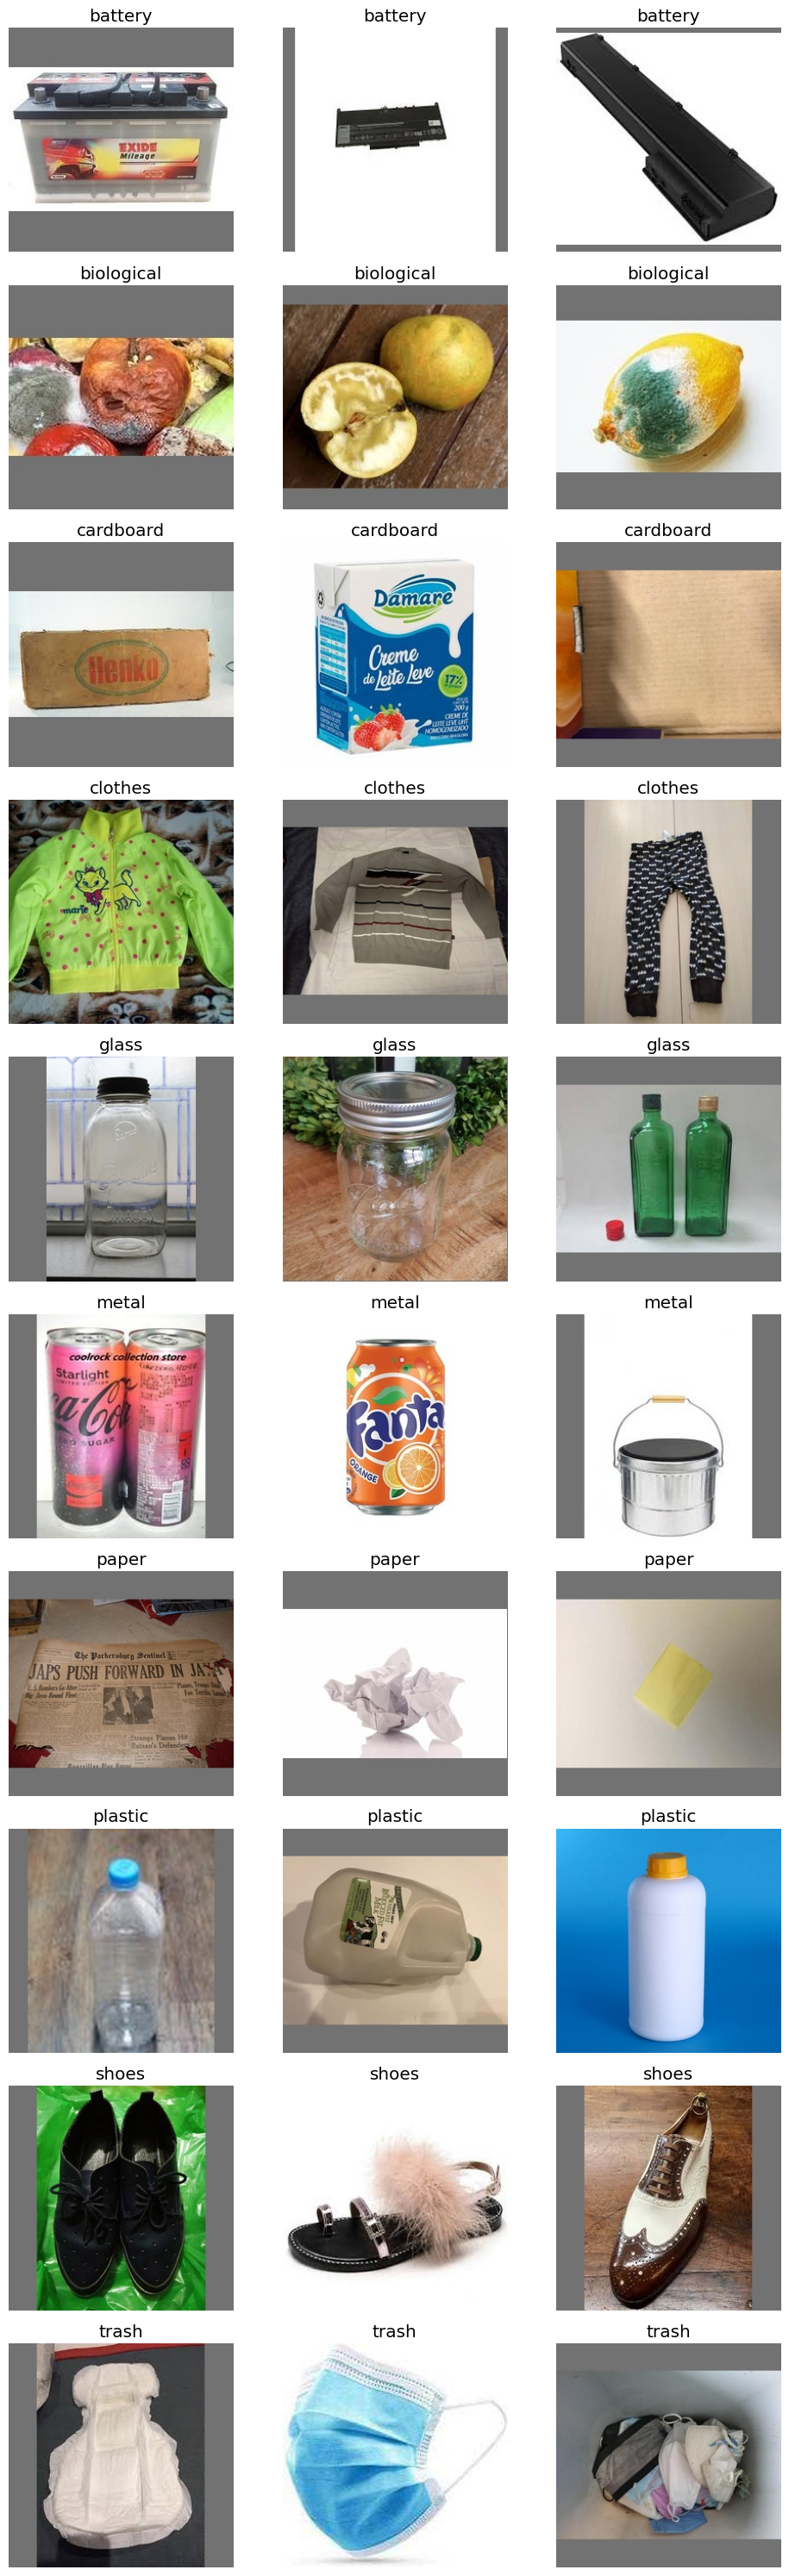

In [38]:
fig, axes = plt.subplots(10,3, figsize=(10,30))
for row, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    images = random.sample(os.listdir(folder),3)
    
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(folder,img_name))
        axes[row,col].imshow(img)
        axes[row,col].set_title(cls)
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

In [39]:
bad_images = []
for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(folder):
        path = os.path.join(folder,img_name)
        try:
            Image.open(path).verify()
        except:
            bad_images.append(path)

print("Corrupted Images :",len(bad_images))

Corrupted Images : 0


# Data Splitting

In [40]:
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

splitfolders.ratio(
    DATASET_PATH,
    output=OUTPUT_PATH,
    seed=42,
    ratio=(0.8, 0.1, 0.1),
    move=False 
)

Copying files: 12259 files [00:12, 994.72 files/s] 


In [41]:
train_path = os.path.join(OUTPUT_PATH, "train")
val_path   = os.path.join(OUTPUT_PATH, "val")
test_path  = os.path.join(OUTPUT_PATH, "test")

print(train_path)
print(val_path)
print(test_path)

/kaggle/working/garbage_dataset/train
/kaggle/working/garbage_dataset/val
/kaggle/working/garbage_dataset/test


In [42]:
## Build
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)


val_test_gen = ImageDataGenerator(
    rescale=1./255
)

In [43]:
## USE
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = train_gen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)
val_data = val_test_gen.flow_from_directory(
    val_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_data = val_test_gen.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

NUM_CLASSES = train_data.num_classes

Found 9802 images belonging to 10 classes.
Found 1221 images belonging to 10 classes.
Found 1236 images belonging to 10 classes.


# Model 1: MobileNetV2

In [44]:
## Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [45]:
## Class weights(imbalance)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))


In [46]:
## Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

In [47]:
## Train 
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 143s 432ms/step - accuracy: 0.7686 - loss: 0.7006 - val_accuracy: 0.8559 - val_loss: 0.4333 - learning_rate: 0.0010
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 118s 384ms/step - accuracy: 0.8482 - loss: 0.4493 - val_accuracy: 0.8796 - val_loss: 0.3616 - learning_rate: 0.0010
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 118s 385ms/step - accuracy: 0.8694 - loss: 0.3727 - val_accuracy: 0.8878 - val_loss: 0.3369 - learning_rate: 0.0010
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 117s 380ms/step - accuracy: 0.8865 - loss: 0.3243 - val_accuracy: 0.8837 - val_loss: 0.3274 - learning_rate: 0.0010
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 119s 386ms/step - accuracy: 0.8934 - loss: 0.2944 - val_accuracy: 0.8952 - val_loss: 0.3174 - learning_rate: 0.0010
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 118s 385ms/step - accuracy: 0.8988 - loss: 0.2787 - val_accuracy: 0.8911 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 120s 391ms/step - accura

In [48]:
## Fine-tuning 
base_model.trainable = True
# Just unlock the last 30 layers, leave the rest frozen
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10


2026-08-05 17:14:20.021188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:14:20.218562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


191/307 ━━━━━━━━━━━━━━━━━━━━ 43s 375ms/step - accuracy: 0.7820 - loss: 0.6863

2026-08-05 17:15:39.039417: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:15:39.235448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


307/307 ━━━━━━━━━━━━━━━━━━━━ 148s 431ms/step - accuracy: 0.8323 - loss: 0.5057 - val_accuracy: 0.9066 - val_loss: 0.2749 - learning_rate: 1.0000e-05
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 120s 392ms/step - accuracy: 0.8792 - loss: 0.3388 - val_accuracy: 0.9066 - val_loss: 0.2851 - learning_rate: 1.0000e-05
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 119s 388ms/step - accuracy: 0.8942 - loss: 0.2885 - val_accuracy: 0.9091 - val_loss: 0.2834 - learning_rate: 1.0000e-05
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 117s 382ms/step - accuracy: 0.9068 - loss: 0.2598 - val_accuracy: 0.9075 - val_loss: 0.2843 - learning_rate: 5.0000e-06
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 117s 381ms/step - accuracy: 0.9071 - loss: 0.2594 - val_accuracy: 0.9050 - val_loss: 0.2848 - learning_rate: 5.0000e-06


In [49]:
## Evaluation
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 207ms/step - accuracy: 0.8981 - loss: 0.3451
Test Accuracy: 0.8981


In [50]:
# Predictions
test_data.reset()
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_data.classes

class_labels = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step
              precision    recall  f1-score   support

     battery       0.94      0.95      0.94        77
  biological       0.96      0.97      0.97        71
   cardboard       0.88      0.89      0.88       142
     clothes       0.98      0.98      0.98       190
       glass       0.90      0.85      0.87       175
       metal       0.74      0.94      0.83        93
       paper       0.87      0.79      0.83       135
     plastic       0.86      0.85      0.85       161
       shoes       0.99      0.96      0.97       146
       trash       0.78      0.78      0.78        46

    accuracy                           0.90      1236
   macro avg       0.89      0.90      0.89      1236
weighted avg       0.90      0.90      0.90      1236



In [51]:
# MobileNetV2
model.save('mobilenetv2_garbage_classifier.keras')

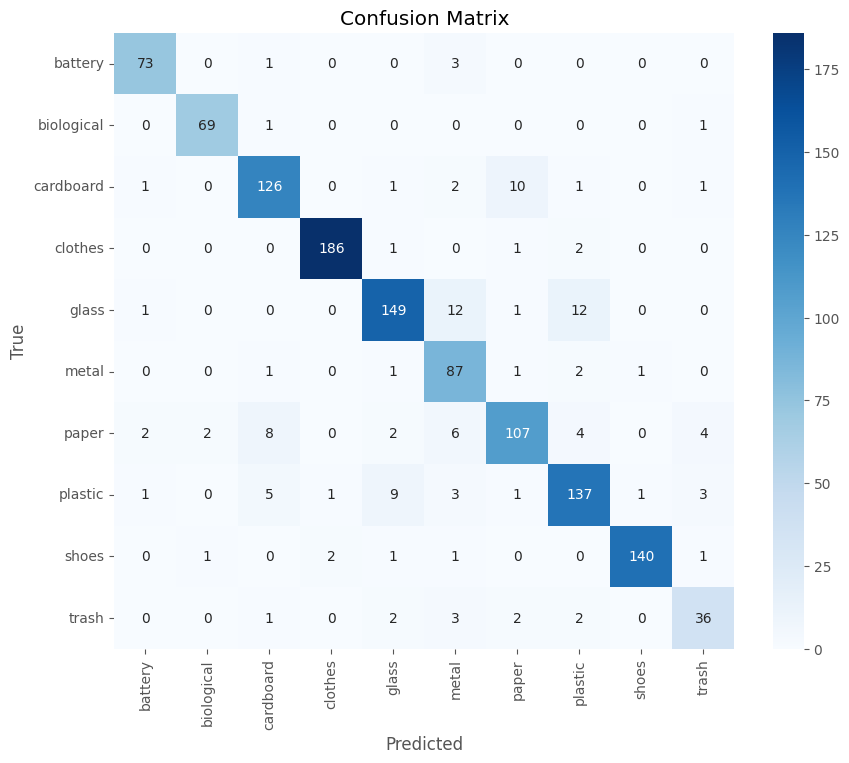

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Model 2: EfficientNetB0

In [53]:
# Data Generators
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)


In [54]:
val_test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=32, class_mode='categorical'
)
val_data = val_test_gen.flow_from_directory(
    val_path, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)
test_data = val_test_gen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

NUM_CLASSES = train_data.num_classes

Found 9802 images belonging to 10 classes.
Found 1221 images belonging to 10 classes.
Found 1236 images belonging to 10 classes.


In [55]:
# Model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model_eff = Model(inputs=base_model.input, outputs=output)

model_eff.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [56]:
# Train head
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 163s 468ms/step - accuracy: 0.8528 - loss: 0.4741 - val_accuracy: 0.9287 - val_loss: 0.2011 - learning_rate: 0.0010
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 134s 436ms/step - accuracy: 0.9185 - loss: 0.2394 - val_accuracy: 0.9279 - val_loss: 0.2001 - learning_rate: 0.0010
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 131s 427ms/step - accuracy: 0.9356 - loss: 0.1827 - val_accuracy: 0.9361 - val_loss: 0.1841 - learning_rate: 0.0010
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 124s 405ms/step - accuracy: 0.9443 - loss: 0.1555 - val_accuracy: 0.9443 - val_loss: 0.1758 - learning_rate: 0.0010
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 122s 397ms/step - accuracy: 0.9563 - loss: 0.1254 - val_accuracy: 0.9443 - val_loss: 0.1569 - learning_rate: 0.0010
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 118s 386ms/step - accuracy: 0.9627 - loss: 0.1077 - val_accuracy: 0.9533 - val_loss: 0.1509 - learning_rate: 0.0010
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 118s 384ms/step - accura

In [57]:
# Fine-tuning 
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_eff.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff_fine = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10


2026-08-05 17:56:12.270695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:56:12.477753: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:56:12.887236: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:56:13.094339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 64/307 ━━━━━━━━━━━━━━━━━━━━ 1:37 403ms/step - accuracy: 0.9045 - loss: 0.2327

2026-08-05 17:56:52.759035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:56:52.964299: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:56:53.339853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 17:56:53.545096: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


307/307 ━━━━━━━━━━━━━━━━━━━━ 186s 511ms/step - accuracy: 0.9093 - loss: 0.2516 - val_accuracy: 0.9255 - val_loss: 0.2128 - learning_rate: 1.0000e-05
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 423ms/step - accuracy: 0.9340 - loss: 0.1825 - val_accuracy: 0.9263 - val_loss: 0.2027 - learning_rate: 1.0000e-05
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 127s 413ms/step - accuracy: 0.9436 - loss: 0.1560 - val_accuracy: 0.9328 - val_loss: 0.1871 - learning_rate: 1.0000e-05
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 122s 397ms/step - accuracy: 0.9521 - loss: 0.1359 - val_accuracy: 0.9353 - val_loss: 0.1836 - learning_rate: 5.0000e-06
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 117s 382ms/step - accuracy: 0.9541 - loss: 0.1277 - val_accuracy: 0.9386 - val_loss: 0.1798 - learning_rate: 5.0000e-06


In [58]:
# Evaluation 
test_loss, test_acc = model_eff.evaluate(test_data)
print(f"EfficientNetB0 Test Accuracy: {test_acc:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.9167 - loss: 0.2917
EfficientNetB0 Test Accuracy: 0.9167


In [60]:
# EfficientNetB0
model_eff.save('efficientnetb0_garbage_classifier.keras')

# Model Comparison

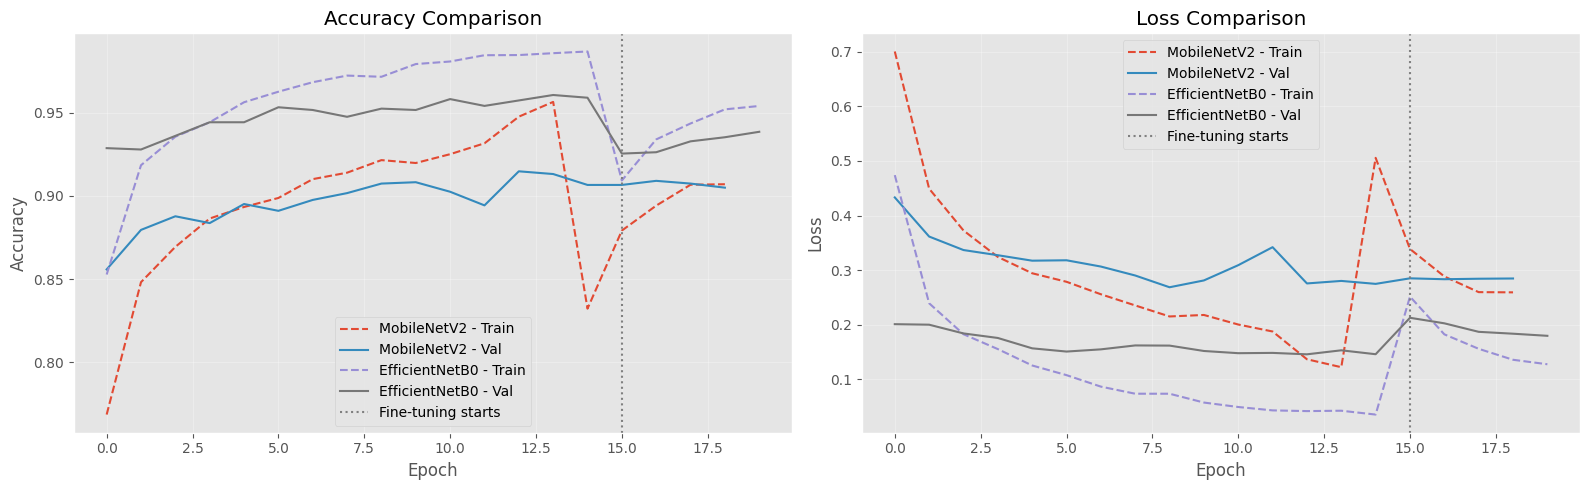

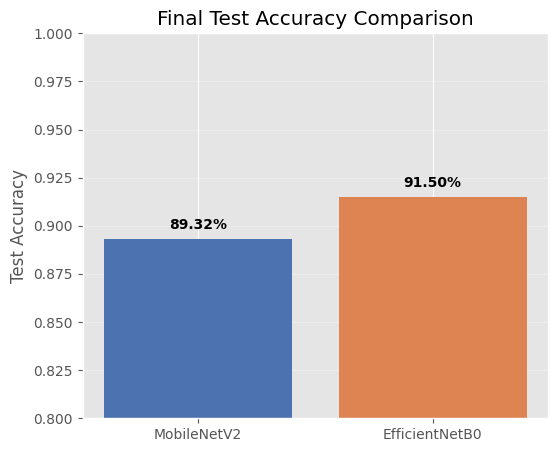

In [62]:
mobilenet_acc = history.history['accuracy'] + history_fine.history['accuracy']
mobilenet_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
mobilenet_loss = history.history['loss'] + history_fine.history['loss']
mobilenet_val_loss = history.history['val_loss'] + history_fine.history['val_loss']

eff_acc = history_eff.history['accuracy'] + history_eff_fine.history['accuracy']
eff_val_acc = history_eff.history['val_accuracy'] + history_eff_fine.history['val_accuracy']
eff_loss = history_eff.history['loss'] + history_eff_fine.history['loss']
eff_val_loss = history_eff.history['val_loss'] + history_eff_fine.history['val_loss']

# Accuracy Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(mobilenet_acc, label='MobileNetV2 - Train', linestyle='--')
axes[0].plot(mobilenet_val_acc, label='MobileNetV2 - Val')
axes[0].plot(eff_acc, label='EfficientNetB0 - Train', linestyle='--')
axes[0].plot(eff_val_acc, label='EfficientNetB0 - Val')
axes[0].axvline(x=15, color='gray', linestyle=':', label='Fine-tuning starts')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mobilenet_loss, label='MobileNetV2 - Train', linestyle='--')
axes[1].plot(mobilenet_val_loss, label='MobileNetV2 - Val')
axes[1].plot(eff_loss, label='EfficientNetB0 - Train', linestyle='--')
axes[1].plot(eff_val_loss, label='EfficientNetB0 - Val')
axes[1].axvline(x=15, color='gray', linestyle=':', label='Fine-tuning starts')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150)
plt.show()

# Bar chart: Test Accuracy
models_names = ['MobileNetV2', 'EfficientNetB0']
test_accuracies = [0.8932, 0.9150] 

plt.figure(figsize=(6, 5))
bars = plt.bar(models_names, test_accuracies, color=['#4C72B0', '#DD8452'])
plt.ylim(0.8, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Final Test Accuracy Comparison')
for bar, acc in zip(bars, test_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
              f'{acc:.2%}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.savefig('test_accuracy_comparison.png', dpi=150)
plt.show()

# Testing on New Images

In [63]:
def predict_image(img_path, model, class_labels):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    predicted_class = class_labels[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence:.1f}%)")
    plt.show()

    top3_idx = np.argsort(preds)[-3:][::-1]
    print("Top 3 predictions:")
    for i in top3_idx:
        print(f"  {class_labels[i]}: {preds[i]*100:.2f}%")

    return predicted_class, confidence

True label: battery
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


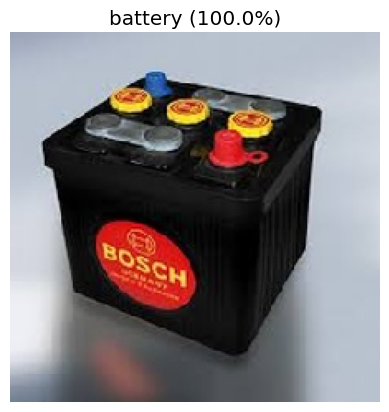

Top 3 predictions:
  battery: 100.00%
  glass: 0.00%
  plastic: 0.00%


('battery', np.float32(99.99827))

In [64]:
test_class = random.choice(os.listdir(test_path))
test_images = os.listdir(os.path.join(test_path, test_class))
random_img = random.choice(test_images)
img_path = os.path.join(test_path, test_class, random_img)

print(f"True label: {test_class}")
predict_image(img_path, model, class_labels)

In [65]:
def gradio_predict(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)[0]
    return {class_labels[i]: float(preds[i]) for i in range(len(class_labels))}

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Garbage Classifier"
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9bb53c8ac39d4080ed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
